# Attention: What It Is, Why It Exists, and How the Maths Works

This notebook builds the attention mechanism from scratch — not as a list of facts, but as a series of problems that demand a solution.

By the end you will understand:
- **Why** attention was invented (what broke before it)
- **What** it actually computes, step by step
- **The equation** — where every symbol comes from
- **Multi-head attention** — why one attention isn't enough
- **Self-attention** — the version that powers transformers

---

## Part 1 — The Problem Attention Was Invented to Solve

Before attention existed, sequence-to-sequence models (translation, summarisation, etc.) worked like this:

1. An **encoder** reads the entire input, one token at a time
2. It produces a single fixed-size vector — the **context vector** — that is supposed to summarise everything
3. A **decoder** generates the output using only that one vector

```
[token1] → [token2] → [token3] → [token4] → [context vector] → [output]
```

### The bottleneck problem

Imagine trying to summarise a 500-word paragraph into a single 256-dimensional vector, then asking someone to reconstruct the paragraph from only that vector. Information gets crushed.

In practice: short sentences translated fine. Long sentences degraded noticeably. The fixed-size context vector was the bottleneck.

### The insight (Bahdanau et al., 2015)

Instead of squashing everything into one vector, what if the decoder could **look back** at all the encoder states, and decide which ones to focus on at each step of decoding?

Not a fixed summary. A **dynamic, weighted average** that changes depending on what the decoder is currently trying to produce.

That dynamic weighted average *is* attention.

## Part 2 — Building Attention from First Principles

Let's forget language entirely and work with raw numbers.

### The core idea as a recipe

Suppose you have:
- A **query** vector — *what you're looking for*
- A set of **key** vectors — *what each piece of stored information advertises itself as*
- A set of **value** vectors — *the actual content of each piece of stored information*

Attention works in three steps:

1. **Score**: compare the query against every key → how relevant is each piece?
2. **Normalise**: turn those scores into weights that sum to 1 (softmax)
3. **Aggregate**: take a weighted sum of the values

The output is a single vector — a blend of all values, weighted by how relevant each was to the query.

---

Let's build each step with actual numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

print("Libraries loaded.")

Libraries loaded.


### Step 1 — Set up a simple scenario

We have **4 items** in memory (think of them as 4 tokens, 4 database rows, whatever you like).  
Each is represented as a **3-dimensional vector**.

We also have a **query** — something we're trying to find a relevant response to, also a 3-dimensional vector.

In [2]:
# 4 items, each described by a 3-dimensional key vector
# Think of these as: "how each item describes itself"
keys = np.array([
    [1.0, 0.0, 0.0],   # item 0: strongly in direction 1
    [0.0, 1.0, 0.0],   # item 1: strongly in direction 2
    [0.9, 0.1, 0.0],   # item 2: mostly like item 0
    [0.0, 0.0, 1.0],   # item 3: strongly in direction 3
])

# The same 4 items have value vectors — the actual content we want to retrieve
# These don't have to be the same as keys (and in real transformers, they're not)
values = np.array([
    [10.0,  0.0,  0.0],
    [ 0.0, 20.0,  0.0],
    [ 8.0,  2.0,  0.0],
    [ 0.0,  0.0, 30.0],
])

# Our query: what we're looking for
# This one looks a lot like item 0 and item 2
query = np.array([1.0, 0.1, 0.0])

print("Keys (shape:", keys.shape, "):")
print(keys)
print("\nValues (shape:", values.shape, "):")
print(values)
print("\nQuery:", query)

Keys (shape: (4, 3) ):
[[1.  0.  0. ]
 [0.  1.  0. ]
 [0.9 0.1 0. ]
 [0.  0.  1. ]]

Values (shape: (4, 3) ):
[[10.  0.  0.]
 [ 0. 20.  0.]
 [ 8.  2.  0.]
 [ 0.  0. 30.]]

Query: [1.  0.1 0. ]


### Step 2 — Score: how similar is the query to each key?

We use the **dot product** to measure similarity.

The dot product of two vectors is a scalar that is:
- **Large and positive** when vectors point in the same direction
- **Zero** when vectors are perpendicular
- **Negative** when vectors point in opposite directions

$$\text{score}_i = \mathbf{q} \cdot \mathbf{k}_i$$

For each of our 4 keys, we compute one score.

In [3]:
# Dot product of query with each key
raw_scores = keys @ query   # matrix-vector product gives all 4 dot products at once

print("Raw attention scores (query · each key):")
for i, score in enumerate(raw_scores):
    print(f"  Item {i}: {keys[i]} · {query} = {score:.3f}")

print("\nRaw scores:", raw_scores)

Raw attention scores (query · each key):
  Item 0: [1. 0. 0.] · [1.  0.1 0. ] = 1.000
  Item 1: [0. 1. 0.] · [1.  0.1 0. ] = 0.100
  Item 2: [0.9 0.1 0. ] · [1.  0.1 0. ] = 0.910
  Item 3: [0. 0. 1.] · [1.  0.1 0. ] = 0.000

Raw scores: [1.   0.1  0.91 0.  ]


Notice that items 0 and 2 score highest — they're most similar to our query. Item 3 scores zero (perpendicular in the key space).

---

### The scaling problem

In real transformers, vectors have high dimensionality (512, 768, even 4096). As dimensionality grows, dot products can become very large, which causes a problem: when you feed large numbers into softmax, the gradient becomes tiny (the function saturates), and learning slows down or stops.

The fix: **divide by √d_k**, where d_k is the dimension of the key vectors.

$$\text{scaled score}_i = \frac{\mathbf{q} \cdot \mathbf{k}_i}{\sqrt{d_k}}$$

This is why the full operation is called **Scaled Dot-Product Attention**.

In [4]:
d_k = keys.shape[1]   # dimension of key vectors = 3
scaled_scores = raw_scores / np.sqrt(d_k)

print(f"d_k = {d_k},  sqrt(d_k) = {np.sqrt(d_k):.3f}")
print("\nScaled scores:", scaled_scores)
print("(Scores divided by", round(np.sqrt(d_k), 3), ")")

d_k = 3,  sqrt(d_k) = 1.732

Scaled scores: [0.577 0.058 0.525 0.   ]
(Scores divided by 1.732 )


### Step 3 — Normalise with Softmax

We need the scores to become **weights that sum to 1** — a probability distribution over the items.

Softmax does exactly this:

$$\text{weight}_i = \frac{e^{\text{score}_i}}{\sum_j e^{\text{score}_j}}$$

Key properties of softmax:
- All outputs are between 0 and 1
- They sum to exactly 1
- Larger scores get **disproportionately** higher weights (the exp amplifies differences)
- Nothing gets completely ignored (weights are never exactly 0)

In [5]:
def softmax(x):
    """Numerically stable softmax."""
    e = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e / e.sum()

weights = softmax(scaled_scores)

print("Attention weights (after softmax):")
for i, w in enumerate(weights):
    bar = '█' * int(w * 40)
    print(f"  Item {i}: {w:.4f}  {bar}")

print(f"\nSum of weights: {weights.sum():.6f}  (should be 1.0)")

Attention weights (after softmax):
  Item 0: 0.3220  ████████████
  Item 1: 0.1915  ███████
  Item 2: 0.3057  ████████████
  Item 3: 0.1808  ███████

Sum of weights: 1.000000  (should be 1.0)


Items 0 and 2 have the highest weights. Item 3 has some weight — softmax never fully suppresses anything.

---

### Step 4 — Aggregate: weighted sum of values

Now we use these weights to blend the value vectors:

$$\text{output} = \sum_i \text{weight}_i \cdot \mathbf{v}_i$$

The result is a single vector — a mixture of all values, where items more similar to the query contribute more.

In [6]:
# Weighted sum of value vectors
output = weights @ values   # (4,) @ (4, 3) → (3,)

print("Value vectors and their weights:")
for i in range(len(weights)):
    contribution = weights[i] * values[i]
    print(f"  Item {i}: weight={weights[i]:.4f}  value={values[i]}  contribution={contribution}")

print("\nFinal attention output:", output)
print("\nNotice: output is dominated by items 0 and 2 (the ones most similar to the query)")

Value vectors and their weights:
  Item 0: weight=0.3220  value=[10.  0.  0.]  contribution=[3.22 0.   0.  ]
  Item 1: weight=0.1915  value=[ 0. 20.  0.]  contribution=[0.   3.83 0.  ]
  Item 2: weight=0.3057  value=[8. 2. 0.]  contribution=[2.446 0.611 0.   ]
  Item 3: weight=0.1808  value=[ 0.  0. 30.]  contribution=[0.    0.    5.423]

Final attention output: [5.666 4.442 5.423]

Notice: output is dominated by items 0 and 2 (the ones most similar to the query)


That's it. That's the complete attention computation.

---

## Part 3 — The Full Equation

Everything we just did can be written in one line:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Let's decode every symbol:

| Symbol | Shape | What it is |
|--------|-------|-----------|
| $Q$ | (queries × d_k) | The query matrix — one row per query |
| $K$ | (items × d_k) | The key matrix — one row per item |
| $V$ | (items × d_v) | The value matrix — one row per item |
| $QK^T$ | (queries × items) | All query-key dot products at once |
| $/ \sqrt{d_k}$ | — | Scaling to prevent gradient vanishing |
| softmax(…) | (queries × items) | Attention weights — rows sum to 1 |
| × V | (queries × d_v) | Weighted sum of values |

In practice Q, K and V don't come directly from the raw input. They're produced by multiplying the input by **learned weight matrices** $W_Q$, $W_K$, $W_V$. Those matrices are what the network trains — they learn *how* to form useful queries, keys and values.

In [7]:
def scaled_dot_product_attention(Q, K, V):
    """
    Full scaled dot-product attention.
    Q: (n_queries, d_k)
    K: (n_items,   d_k)
    V: (n_items,   d_v)
    Returns: (n_queries, d_v)
    """
    d_k = K.shape[1]
    
    # Score: Q @ K^T  →  (n_queries, n_items)
    scores = Q @ K.T / np.sqrt(d_k)
    
    # Normalise: softmax over items axis
    # Subtract max per row for numerical stability
    scores -= scores.max(axis=1, keepdims=True)
    weights = np.exp(scores)
    weights /= weights.sum(axis=1, keepdims=True)
    
    # Aggregate: weighted sum of values
    output = weights @ V
    
    return output, weights


# Test with our earlier example (single query → wrap in 2D)
Q = query.reshape(1, -1)   # (1, 3)
output_full, weights_full = scaled_dot_product_attention(Q, keys, values)

print("Output from full function:", output_full[0])
print("Matches earlier manual result:", np.allclose(output_full[0], output))

Output from full function: [5.666 4.442 5.423]
Matches earlier manual result: True


---

## Part 4 — Visualising Attention

Let's make the weights visible. When you have multiple queries, you get an **attention map** — a grid showing what each query attended to.

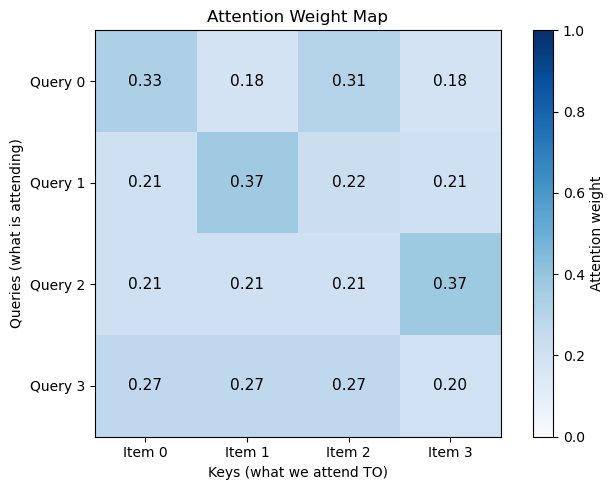

Each row sums to 1.0 — confirmed: True


In [8]:
# Multiple queries — each "looking for" something different
queries = np.array([
    [1.0, 0.0, 0.0],   # Q0: looking for item 0
    [0.0, 1.0, 0.0],   # Q1: looking for item 1
    [0.0, 0.0, 1.0],   # Q2: looking for item 3
    [0.5, 0.5, 0.0],   # Q3: split interest between items 0/1
])

_, attn_weights = scaled_dot_product_attention(queries, keys, values)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(attn_weights, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Attention weight')

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([f'Item {i}' for i in range(4)])
ax.set_yticklabels([f'Query {i}' for i in range(4)])
ax.set_xlabel('Keys (what we attend TO)')
ax.set_ylabel('Queries (what is attending)')
ax.set_title('Attention Weight Map')

# Annotate with values
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{attn_weights[i,j]:.2f}',
                ha='center', va='center',
                color='white' if attn_weights[i,j] > 0.5 else 'black',
                fontsize=11)

plt.tight_layout()
plt.show()

print("Each row sums to 1.0 — confirmed:", np.allclose(attn_weights.sum(axis=1), 1.0))

Query 3 (which was a blend of directions 0 and 1) splits its attention between items 0 and 1, not just item 2 even though item 2 is also in that region — the attention reflects the geometry of the query.

---

## Part 5 — Multi-Head Attention

### The problem with one attention head

One attention operation can only find one kind of relationship at a time. In a sentence like:

> *"The bank by the river had steep banks"*

The word *"bank"* needs to simultaneously:
- Attend to *"river"* to resolve the meaning (semantic relationship)
- Attend to *"had"* to understand its grammatical role (syntactic relationship)

A single attention head produces a single weighted average — it can't track both relationships at once.

### The solution: run h attention heads in parallel

Each head has its **own** learned $W_Q$, $W_K$, $W_V$ matrices.  
Each projects the input into a **different subspace**.  
Each learns to look for a **different kind of relationship**.

The outputs are then concatenated and projected back to the original dimension:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \cdot W^O$$

where each head is:

$$\text{head}_i = \text{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

In [9]:
class MultiHeadAttention:
    def __init__(self, d_model, n_heads, seed=42):
        """
        d_model: total dimension of the model
        n_heads: number of parallel attention heads
        
        Each head operates on dimension d_model // n_heads
        """
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads   # dimension per head
        
        rng = np.random.default_rng(seed)
        
        # Each head has its own projection matrices
        # In real transformers these are learned; here we initialise randomly
        self.W_Q = [rng.normal(0, 0.3, (d_model, self.d_k)) for _ in range(n_heads)]
        self.W_K = [rng.normal(0, 0.3, (d_model, self.d_k)) for _ in range(n_heads)]
        self.W_V = [rng.normal(0, 0.3, (d_model, self.d_k)) for _ in range(n_heads)]
        
        # Output projection: concatenated heads → d_model
        self.W_O = rng.normal(0, 0.3, (d_model, d_model))
    
    def forward(self, X):
        """
        X: (seq_len, d_model) — input sequence
        Returns: (seq_len, d_model) — same shape
        """
        head_outputs = []
        head_weights = []
        
        for i in range(self.n_heads):
            # Project input into this head's Q, K, V spaces
            Q_i = X @ self.W_Q[i]   # (seq_len, d_k)
            K_i = X @ self.W_K[i]
            V_i = X @ self.W_V[i]
            
            # Run attention in this subspace
            out_i, w_i = scaled_dot_product_attention(Q_i, K_i, V_i)
            head_outputs.append(out_i)
            head_weights.append(w_i)
        
        # Concatenate all head outputs along feature dimension
        concat = np.concatenate(head_outputs, axis=1)   # (seq_len, d_model)
        
        # Final linear projection
        output = concat @ self.W_O.T
        
        return output, head_weights


# Example: 6 tokens, each represented as a 8-dimensional vector, 2 heads
d_model = 8
n_heads = 2
seq_len = 6

rng = np.random.default_rng(0)
X = rng.normal(0, 1, (seq_len, d_model))

mha = MultiHeadAttention(d_model, n_heads)
output, head_weights = mha.forward(X)

print(f"Input shape:  {X.shape}")
print(f"Output shape: {output.shape}  (same — multi-head preserves dimensions)")
print(f"\nHead 0 attention weights shape: {head_weights[0].shape}")
print(f"Head 1 attention weights shape: {head_weights[1].shape}")

Input shape:  (6, 8)
Output shape: (6, 8)  (same — multi-head preserves dimensions)

Head 0 attention weights shape: (6, 6)
Head 1 attention weights shape: (6, 6)


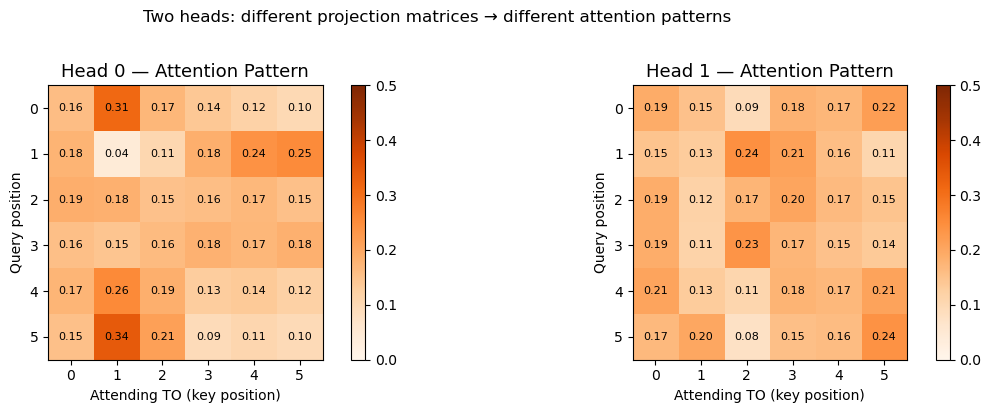


Because each head projects through different W_Q/W_K/W_V matrices,
they compute attention in completely different subspaces.
The patterns above are different — even though the input X was identical.


In [10]:
# Visualise both heads: do they learn to attend to different things?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for h, ax in enumerate(axes):
    im = ax.imshow(head_weights[h], cmap='Oranges', vmin=0, vmax=0.5)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Head {h} — Attention Pattern', fontsize=13)
    ax.set_xlabel('Attending TO (key position)')
    ax.set_ylabel('Query position')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{head_weights[h][i,j]:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if head_weights[h][i,j] > 0.35 else 'black')

plt.suptitle('Two heads: different projection matrices → different attention patterns', y=1.02)
plt.tight_layout()
plt.show()

print("\nBecause each head projects through different W_Q/W_K/W_V matrices,")
print("they compute attention in completely different subspaces.")
print("The patterns above are different — even though the input X was identical.")

---

## Part 6 — Self-Attention: the Heart of Transformers

Everything so far has treated Q, K and V as potentially coming from different sources (the original encoder-decoder framing).

**Self-attention** is a special case: **Q, K and V all come from the same sequence.**

Every token in a sequence attends to every other token in the same sequence. This is how transformers build up contextual representations — each position's output is a blend of all positions, weighted by how much they "need to" interact.

### Why this is powerful

In an RNN, information travels one step at a time — a token at position 0 can only influence position 10 through 10 intermediate steps.

In self-attention, **every position attends to every other position directly** — path length 1, regardless of sequence length. Long-range dependencies become as easy as short-range ones.

Input X shape:  (5, 6)  (5 tokens, 6 dims each)
Output shape:   (5, 6)  (same — self-attention is shape-preserving)
Weights shape:  (5, 5)  (5×5: each token × every other token)


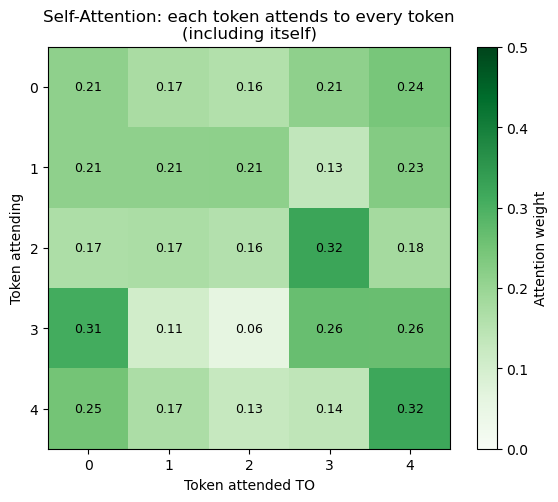

In [11]:
def self_attention(X, W_Q, W_K, W_V):
    """
    Self-attention: Q, K, V all derived from the same input X.
    X:   (seq_len, d_model)
    W_Q, W_K, W_V: (d_model, d_k) projection matrices
    """
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    return scaled_dot_product_attention(Q, K, V)


# 5-token sequence, 6-dimensional representations
seq_len = 5
d_model = 6
d_k = 6

rng = np.random.default_rng(7)
X = rng.normal(0, 1, (seq_len, d_model))

# Random projection matrices (in real transformers, these are trained)
W_Q = rng.normal(0, 0.4, (d_model, d_k))
W_K = rng.normal(0, 0.4, (d_model, d_k))
W_V = rng.normal(0, 0.4, (d_model, d_k))

out, weights = self_attention(X, W_Q, W_K, W_V)

print(f"Input X shape:  {X.shape}  (5 tokens, 6 dims each)")
print(f"Output shape:   {out.shape}  (same — self-attention is shape-preserving)")
print(f"Weights shape:  {weights.shape}  (5×5: each token × every other token)")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights, cmap='Greens', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='Attention weight')
ax.set_title('Self-Attention: each token attends to every token\n(including itself)', fontsize=12)
ax.set_xlabel('Token attended TO')
ax.set_ylabel('Token attending')

for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{weights[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if weights[i,j] > 0.35 else 'black')

plt.tight_layout()
plt.show()

---

## Part 7 — Causal (Masked) Attention

Self-attention as shown above lets every token see every other token — past **and** future. This is fine for encoders (e.g. BERT), but if you're generating text, you can't look at tokens that haven't been generated yet.

**Causal masking** solves this: before applying softmax, we set all positions *above the diagonal* to −∞. Those become 0 after softmax, so future positions contribute nothing.

$$\text{score}_{ij} = \begin{cases} \frac{\mathbf{q}_i \cdot \mathbf{k}_j}{\sqrt{d_k}} & \text{if } j \leq i \\ -\infty & \text{if } j > i \end{cases}$$

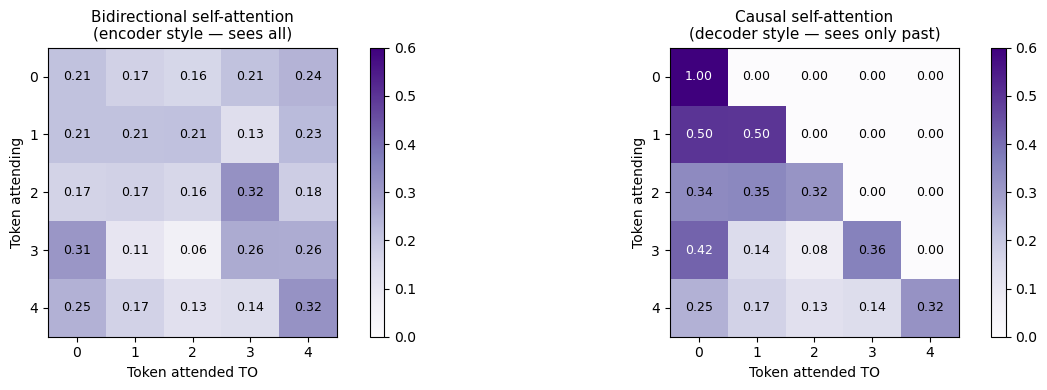

Notice the upper triangle is zero in causal attention.
Token 0 only attends to itself. Token 4 attends to all five.


In [12]:
def causal_self_attention(X, W_Q, W_K, W_V):
    """
    Self-attention with causal mask — token i can only attend to positions 0..i.
    """
    seq_len = X.shape[0]
    d_k = W_K.shape[1]
    
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    
    scores = Q @ K.T / np.sqrt(d_k)
    
    # Causal mask: set upper triangle to -inf
    mask = np.triu(np.ones((seq_len, seq_len)), k=1).astype(bool)
    scores[mask] = -np.inf
    
    # Softmax (handle -inf → 0 correctly)
    scores -= np.where(np.isfinite(scores), scores.max(axis=1, keepdims=True), 0)
    weights = np.exp(np.where(np.isfinite(scores), scores, -1e10))
    weights /= weights.sum(axis=1, keepdims=True)
    
    output = weights @ V
    return output, weights


out_causal, weights_causal = causal_self_attention(X, W_Q, W_K, W_V)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, w, title in zip(axes,
                         [weights, weights_causal],
                         ['Bidirectional self-attention\n(encoder style — sees all)',
                          'Causal self-attention\n(decoder style — sees only past)']):
    im = ax.imshow(w, cmap='Purples', vmin=0, vmax=0.6)
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Token attended TO')
    ax.set_ylabel('Token attending')
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{w[i,j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if w[i,j] > 0.4 else 'black')

plt.tight_layout()
plt.show()

print("Notice the upper triangle is zero in causal attention.")
print("Token 0 only attends to itself. Token 4 attends to all five.")

---

## Part 8 — Everything Together: The Transformer Block

A transformer layer stacks:
1. **Multi-head self-attention** (what we just built)
2. **Add & Norm** — residual connection + layer normalisation
3. **Feed-forward network** — two linear layers with a nonlinearity (acts on each position independently)
4. **Add & Norm** again

```
Input
  │
  ├──→ Multi-Head Self-Attention ──→ + ──→ LayerNorm ──→
  │                                  ↑
  └──────────── (residual) ──────────┘
       │
       ├──→ Feed-Forward Network ──→ + ──→ LayerNorm ──→ Output
       │                              ↑
       └──────── (residual) ──────────┘
```

The residual connections (`+ input`) are critical — they allow gradients to flow backwards through many layers without vanishing, which is what makes transformers trainable at depth.

GPT-2 stacks 12 of these blocks. GPT-3 stacks 96.

In [13]:
def layer_norm(X, eps=1e-6):
    """Normalise each row to mean=0, std=1."""
    mean = X.mean(axis=-1, keepdims=True)
    std  = X.std(axis=-1,  keepdims=True)
    return (X - mean) / (std + eps)

def feed_forward(X, W1, W2):
    """Two-layer MLP with ReLU, applied per position."""
    return np.maximum(0, X @ W1) @ W2  # ReLU activation

def transformer_block(X, mha, W1, W2):
    """
    One transformer encoder block.
    X:   (seq_len, d_model)
    """
    # Multi-head self-attention + residual + norm
    attn_out, _ = mha.forward(X)
    X = layer_norm(X + attn_out)       # Add & Norm
    
    # Feed-forward + residual + norm
    ff_out = feed_forward(X, W1, W2)
    X = layer_norm(X + ff_out)         # Add & Norm
    
    return X


# Example pass-through
d_model = 8
d_ff    = 16   # hidden dim in the feed-forward network (usually 4 × d_model)

rng  = np.random.default_rng(99)
X_in = rng.normal(0, 1, (seq_len, d_model))
mha  = MultiHeadAttention(d_model, n_heads=2)
W1   = rng.normal(0, 0.3, (d_model, d_ff))
W2   = rng.normal(0, 0.3, (d_ff, d_model))

X_out = transformer_block(X_in, mha, W1, W2)

print(f"Input shape:  {X_in.shape}")
print(f"Output shape: {X_out.shape}  — transformer blocks are shape-preserving")
print(f"\nInput[0]:  {X_in[0].round(3)}")
print(f"Output[0]: {X_out[0].round(3)}")
print("\nEach token's representation has been updated by attending to all others.")

Input shape:  (5, 8)
Output shape: (5, 8)  — transformer blocks are shape-preserving

Input[0]:  [ 0.082 -0.464  0.051  0.686 -1.757  1.684 -0.458 -0.596]
Output[0]: [ 0.729  0.909 -0.609  1.392 -1.159  0.855 -0.959 -1.158]

Each token's representation has been updated by attending to all others.


---

## Summary — The Full Picture

| Concept | What it does | Why it matters |
|---------|-------------|----------------|
| **Dot-product score** | Measures similarity between query and key | Determines relevance |
| **√d_k scaling** | Prevents large dot products | Keeps gradients healthy |
| **Softmax** | Turns scores into a probability distribution | Makes weights sum to 1 |
| **Weighted sum of values** | Blends information by relevance | The actual output |
| **Q/K/V projections** | Learned transformations of the input | What the network trains |
| **Multi-head** | Parallel attention in different subspaces | Multiple relationship types simultaneously |
| **Self-attention** | Q, K, V from the same sequence | Direct token-to-token paths, no bottleneck |
| **Causal mask** | Block future positions | Required for autoregressive generation |
| **Residual + LayerNorm** | Stabilise training across many layers | Makes deep networks trainable |

---

### The one equation that matters

$$\boxed{\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V}$$

Every component of every transformer — GPT, BERT, Claude — reduces to repeated applications of this equation, learned projection matrices, residual connections, and layer normalisation.

---

## Things to Try

- Change the `query` vector in Part 2 and see how the attention weights shift
- Try making a key identical to the query — does it dominate?
- Increase `n_heads` in the MultiHeadAttention and observe how patterns diverge further
- Set `d_k` very high (e.g. 512) and remove the √d_k scaling — compare the weight distributions before vs after softmax
- Modify the causal mask to create other patterns (e.g. local attention: each token only attends to its 2 nearest neighbours)